In [1]:
import pandas as pd
import numpy as np
import random

In [3]:
class QLearningProductionSystem:
    def __init__(self, max_inventory, min_inventory, max_production, max_demand, backorder_cost, epsilon, learning_rate, discount_factor, lead_time=1):
        self.max_inventory = max_inventory
        self.min_inventory = min_inventory
        self.max_production = max_production
        self.max_demand = max_demand
        self.backorder_cost = backorder_cost
        self.epsilon = epsilon
        self.lead_time = lead_time
        self.production_queue = 0
        self.learning_rate = learning_rate
        self.discount_factor = discount_factor
        # State space now includes inventory, demand, and forecast
        self.inventory_state_size = max_inventory - min_inventory + 1
        self.demand_state_size = max_demand + 1
        self.forecast_state_size = max_demand + 1
        self.action_size = max_production + 1
        self.production_queue_size = self.max_production + 1
        # Expanding Q-table to include all dimensions
        self.q_table = np.zeros((self.inventory_state_size, self.demand_state_size, self.forecast_state_size, self.production_queue_size, self.action_size))
        #self.q_table = np.zeros((self.inventory_state_size, self.demand_state_size, self.forecast_state_size, self.production_queue_size, self.action_size))
        self.current_inventory = 0
        self.forecast = random.randint(0, self.max_demand)

    def get_state_indexes(self, inventory, demand, forecast):
        inventory_index = inventory - self.min_inventory
        demand_index = demand
        forecast_index = forecast
        production_queue_index = min(self.production_queue, self.max_production)
        return inventory_index, demand_index, forecast_index, production_queue_index

    def choose_action(self, inventory, demand, forecast):
        inventory_index, demand_index, forecast_index,production_queue_index = self.get_state_indexes(inventory, demand, forecast)
        if random.uniform(0, 1) < self.epsilon:
            return random.randint(0, self.max_production)  # Explore
        else:
            return np.argmax(self.q_table[inventory_index, demand_index, forecast_index,production_queue_index])  # Exploit

    def update_q_table(self, inventory, demand, forecast, action, reward, next_inventory):
        inventory_index, demand_index, forecast_index, production_queue_index = self.get_state_indexes(inventory, demand, forecast)
        next_inventory_index = next_inventory - self.min_inventory
        # Assume next demand and forecast could be any, but for simplicity, use current demand, forecast for max future Q
        next_max_q = np.max(self.q_table[next_inventory_index, :, :, :, :])

        current_q_value = self.q_table[inventory_index, demand_index, forecast_index, production_queue_index, action]
        # Q-learning update rule
        new_q_value = current_q_value + self.learning_rate * (reward + self.discount_factor * next_max_q - current_q_value)
        self.q_table[inventory_index, demand_index, forecast_index, production_queue_index, action] = new_q_value


    def simulate(self, episodes):
        for episode in range(episodes):
            state = self.current_inventory
            demand = self.forecast
            #print(f"This is demand: {demand} in episode: {episode}")
            forecast = random.randint(0, self.max_demand)
            #print(f"This is forecast: {forecast} in episode: {episode}")
            action = self.choose_action(state, demand, forecast)
            # Add the action to the production queue and remove the oldest action
            production = self.production_queue
            self.production_queue = action
            next_state = min(max(self.current_inventory + production - demand, self.min_inventory), self.max_inventory)
            reward = self.get_reward(state, production, demand, forecast)
            self.update_q_table(state, demand, forecast, action, reward, next_state)
            self.current_inventory = next_state
            self.forecast = forecast

            # Optionally update forecast here
    
    def get_reward(self, state, production, demand, forecast):
        new_inventory = state + production - demand
        # Costs and rewards parameters
        holding_cost_per_unit = 3  # Cost for holding one unit of inventory
        backorder_cost_per_unit = 5  # Cost for each unit backordered
        production_cost_per_unit = 1  # Cost for producing one unit
        sale_reward_per_unit = 10  # Reward for each unit sold (meeting demand)
        forecast_adjustment_factor = 10  # Additional reward factor for preparing for forecasted demand

        # Calculate base reward or penalty
        if new_inventory >= 0:
            # Inventory is sufficient to meet demand
            holding_cost = holding_cost_per_unit * new_inventory
            total_cost = holding_cost + (production * production_cost_per_unit)
            total_reward = (demand * sale_reward_per_unit) - total_cost
        else:
            # Inventory is not sufficient, leading to backorders
            backorder_cost = abs(new_inventory) * backorder_cost_per_unit
            total_cost = backorder_cost + (production * production_cost_per_unit)
            total_reward = (demand * sale_reward_per_unit) - total_cost

        # # Adjust reward based on forecast
        if forecast > self.max_production:
            # When forecasted demand exceeds max production, incentivize building up inventory in advance
            required_inventory = 2 + forecast - self.max_production  # Required inventory to meet the forecasted demand

            # Check if new_inventory exactly matches the required inventory or exceeds it by 1 or 2 units
            if new_inventory == required_inventory:
                # Provide an additional reward for having exactly enough inventory to cover the gap between forecast and max production
                total_reward += 80
            elif new_inventory == required_inventory - 1:
                # Provide an additional reward for having inventory that exceeds the required by exactly 1 unit
                total_reward += 50
            elif new_inventory == required_inventory - 2:
                # Provide an additional reward for having inventory that exceeds the required by exactly 2 units
                total_reward += 30
            elif new_inventory == required_inventory - 3:
                # Provide an additional reward for having inventory that exceeds the required by exactly 2 units
                total_reward += 2



        # Bonus for maintaining optimal inventory level or near to optimal inventory
        optimal_inventory_level = 2  # Defined optimal inventory level (safety stock)
        if  new_inventory == optimal_inventory_level:
            # Adding a small bonus for keeping inventory within the optimal range
            total_reward += 40
        elif  new_inventory == optimal_inventory_level-1:
            # Adding a small bonus for keeping inventory within the optimal range
            total_reward += 20
        elif  new_inventory == optimal_inventory_level+1:
            # Adding a small bonus for keeping inventory within the optimal range
            total_reward += 20

        return total_reward
    
    

    def evaluate_agent(self, demand_array, episodes):
        total_reward = 0
        demand_met_count = 0
        episode_data = []
        self.current_inventory = 0
        self.production_queue = 0

        for episode in range(episodes):
            state = self.current_inventory
            if episode == 0:
                demand = demand_array[episode]
            else:
                demand = self.forecast
            forecast = demand_array[episode+1]
            # Choose the best action based on Q-table, not exploring
            inventory_index, demand_index, forecast_index, production_queue_index = self.get_state_indexes(state, demand, forecast)
            action = np.argmax(self.q_table[inventory_index, demand_index, forecast_index,production_queue_index])
            
            production = self.production_queue
            self.production_queue = action
            
            reward = self.get_reward(state, production, demand, forecast)
            total_reward += reward

            # Update current inventory, keeping it within set limits
            self.current_inventory = min(max(self.current_inventory+ production - demand, self.min_inventory), self.max_inventory)
            self.forecast = forecast

            if state + action >= demand:
                demand_met_count += 1

            # Store state, demand, action, and reward for each episode
            episode_data.append((episode, state, demand, forecast, action, reward))
            # Printing the demand and action for each episode
            #print(f"Episode {episode + 1}: Demand = {demand}, Action = {action}, State = {state}")
        average_reward = total_reward / episodes
        demand_met_rate = demand_met_count / episodes

        return average_reward, demand_met_rate, episode_data

    def save_q_table_to_csv(self, file_path):
        # Flatten the Q-table into a list of rows, each row representing state, action, and corresponding Q-value
        records = []
        for inventory_index in range(self.q_table.shape[0]):
            for demand_index in range(self.q_table.shape[1]):
                for forecast_index in range(self.q_table.shape[2]):
                    for action_index in range(self.q_table.shape[3]):
                        q_value = self.q_table[inventory_index, demand_index, forecast_index, action_index]
                        records.append([inventory_index, demand_index, forecast_index, action_index, q_value])

        # Convert the list of rows into a DataFrame
        df = pd.DataFrame(records, columns=['InventoryIndex', 'DemandIndex', 'ForecastIndex', 'ActionIndex', 'QValue'])

        # Save the DataFrame to a CSV file
        df.to_csv(file_path, index=False)
        print(f"Q-table saved to {file_path}")

In [5]:
# Example usage
max_inventory = 6
min_inventory = -5
max_production = 5
max_demand = 7
backorder_cost =1
epsilon = 0.1  # Exploration rate
learning_rate = 0.12
discount_factor = 0.5

system = QLearningProductionSystem(max_inventory, min_inventory, max_production, max_demand, backorder_cost, epsilon, learning_rate, discount_factor)

system.simulate(episodes=800000)
print(system.q_table)
system.save_q_table_to_csv('Q_Values.csv')

[[[[[ 18.79671614   0.           0.           0.           0.
       0.        ]
    [  0.          37.56928591   0.           0.           0.
       0.        ]
    [  0.           0.          66.94500618   0.           0.
       0.        ]
    [  0.           0.           0.          74.72535354   0.
       0.        ]
    [  0.           0.           0.           0.          72.4110722
       0.        ]
    [  0.           0.           0.           0.           0.
      85.49851357]]

   [[ 24.05340924   0.           0.           0.           0.
       0.        ]
    [  0.          34.17089456   0.           0.           0.
       0.        ]
    [  0.           0.          61.45698046   0.           0.
       0.        ]
    [  0.           0.           0.          79.51611579   0.
       0.        ]
    [  0.           0.           0.           0.          84.35304044
       0.        ]
    [  0.           0.           0.           0.           0.
      82.15820948]]

   [[ 18.

In [13]:
# Evaluate the trained agent and observe output directly from the method
seed_1 = random.randint(0,1000)
#seed_1 = 42
np.random.seed(seed_1)
evaluation_episodes = 50
demand_array = np.random.randint(0, max_demand, size=evaluation_episodes+1)

average_reward, demand_met_rate, Episode_data = system.evaluate_agent(demand_array,evaluation_episodes)

# Print summary statistics
print(f"\nAverage Reward over {evaluation_episodes} evaluation episodes: {average_reward}")
print(f"Demand Met Rate over {evaluation_episodes} evaluation episodes: {demand_met_rate:.2%}")
print(f"Episode data: {Episode_data}")
#episode, state, demand, forecast, action, reward


Average Reward over 50 evaluation episodes: -10.2
Demand Met Rate over 50 evaluation episodes: 0.00%
Episode data: [(0, 0, 4, 0, 0, 20), (1, -4, 0, 3, 0, -20), (2, -4, 3, 1, 0, -5), (3, -5, 1, 5, 0, -20), (4, -5, 5, 6, 0, 0), (5, -5, 6, 2, 0, 5), (6, -5, 2, 6, 0, -15), (7, -5, 6, 1, 0, 5), (8, -5, 1, 5, 0, -20), (9, -5, 5, 4, 0, 0), (10, -5, 4, 2, 0, -5), (11, -5, 2, 2, 0, -15), (12, -5, 2, 3, 0, -15), (13, -5, 3, 6, 0, -10), (14, -5, 6, 1, 0, 5), (15, -5, 1, 2, 0, -20), (16, -5, 2, 1, 0, -15), (17, -5, 1, 4, 0, -20), (18, -5, 4, 5, 0, -5), (19, -5, 5, 0, 0, 0), (20, -5, 0, 4, 0, -25), (21, -5, 4, 5, 0, -5), (22, -5, 5, 0, 0, 0), (23, -5, 0, 0, 0, -25), (24, -5, 0, 3, 0, -25), (25, -5, 3, 2, 0, -10), (26, -5, 2, 4, 0, -15), (27, -5, 4, 6, 0, -5), (28, -5, 6, 0, 0, 5), (29, -5, 0, 5, 0, -25), (30, -5, 5, 3, 0, 0), (31, -5, 3, 4, 0, -10), (32, -5, 4, 5, 0, -5), (33, -5, 5, 0, 0, 0), (34, -5, 0, 2, 0, -25), (35, -5, 2, 6, 0, -15), (36, -5, 6, 1, 0, 5), (37, -5, 1, 2, 0, -20), (38, -5, 2,

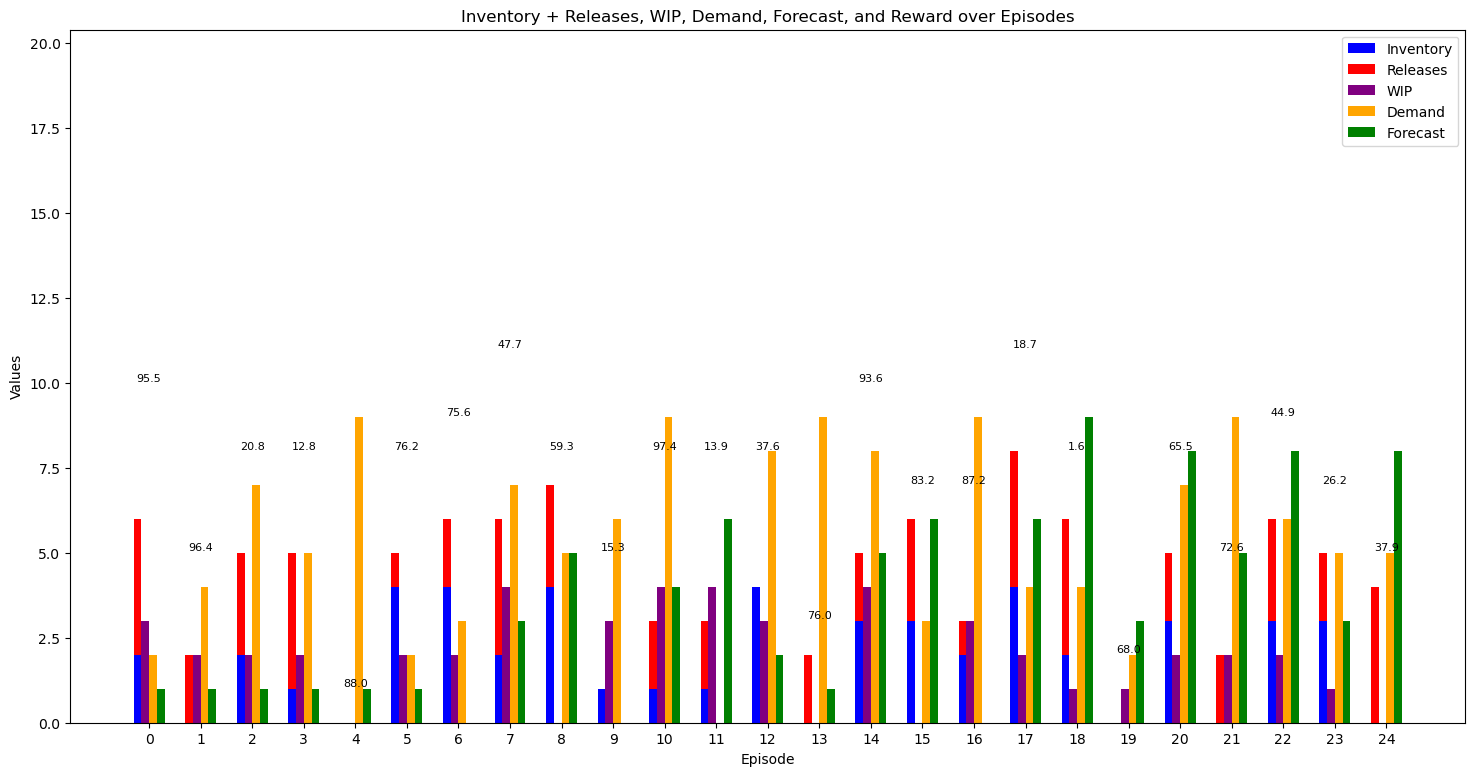

In [15]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random

# Setup for demonstration purposes
max_demand = 10
evaluation_episodes = 25
seed_1 = random.randint(0, 1000)

np.random.seed(seed_1)
demand_array = np.random.randint(0, max_demand, size=evaluation_episodes + 1)

# Mock data to replace system.evaluate_agent call
# Simulate the production_queue_index (WIP) addition
episode_data = [
    (i, np.random.randint(0, 5), np.random.randint(0, 10), np.random.randint(0, 10), np.random.randint(0, 5), np.random.random() * 100, np.random.randint(0, 5)) 
    for i in range(25)
]

# Convert data to DataFrame for easier plotting
df = pd.DataFrame(episode_data, columns=['Episode', 'State', 'Demand', 'Forecast', 'Action', 'Reward', 'WIP'])

# Set up the figure
plt.figure(figsize=(18, 9))
width = 0.15  # Width of the bars

# Iterate over episodes to plot bars and add reward text
for i in range(len(df)):
    # State + Action stacked bar
    # Inventory bar
    plt.bar(i - 2*width, df.loc[i, 'State'], width, label='Inventory' if i == 0 else "", color='blue')
    
    # Action bar
    plt.bar(i - width, df.loc[i, 'Action'], width, label='Releases' if i == 0 else "", color='red')
    
    # WIP bar
    plt.bar(i - width/2, df.loc[i, 'WIP'], width, label='WIP' if i == 0 else "", color='purple')

    # Demand bar
    plt.bar(i + width/2, df.loc[i, 'Demand'], width, label='Demand' if i == 0 else "", color='orange')

    # Forecast bar
    plt.bar(i + 1.5*width, df.loc[i, 'Forecast'], width, label='Forecast' if i == 0 else "", color='green')

    # Add reward text
    reward = df.loc[i, 'Reward']
    plt.text(i, df.loc[i, 'State'] + df.loc[i, 'Action'] + df.loc[i, 'WIP'] + 1, f'{reward:.1f}', ha='center', va='bottom', color='black', fontsize=8)

# Add labels and title
plt.xlabel('Episode')
plt.ylabel('Values')
plt.title('Inventory + Releases, WIP, Demand, Forecast, and Reward over Episodes')
plt.xticks(range(len(df)), df['Episode'])

# Adjust the plot limits if necessary
plt.ylim([0, max(df['State'] + df['Action'] + df['WIP'] + df['Demand']) * 1.2])

# Add legend
plt.legend()

# Show plot
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd


seed_1 = random.randint(0,1000)

np.random.seed(seed_1)
demand_array = np.random.randint(0, max_demand, size=evaluation_episodes+1)

# Assuming you have already run the simulation and have the episode_data
average_reward, demand_met_rate, episode_data = system.evaluate_agent(demand_array,25)

# Convert data to DataFrame for easier plotting
df = pd.DataFrame(episode_data, columns=['Episode', 'State', 'Demand', 'Forecast', 'Action', 'Reward'])

# Set up the figure
plt.figure(figsize=(15, 7))
width = 0.15  # Adjust width to fit all bars

# Iterate over episodes to plot bars and add reward text
for i in range(len(df)):
    state = df.loc[i, 'State']
    action = df.loc[i, 'Action']
    demand = df.loc[i, 'Demand']
    forecast = df.loc[i, 'Forecast']

    # Plotting state and action
    if state >= 0:
        plt.bar(i - width, state, width, label='Inventory' if i == 0 else "", color='blue')
    else:
        plt.plot(i - width, abs(state), width, label='Backorder' if i == 0 else "", color='cyan', linestyle='none', marker='o')
    plt.bar(i - width, action, width, bottom=max(state, 0), label='Production' if i == 0 else "", color='red')
    
    # Plotting demand and forecast with adjusted positions
    plt.bar(i, demand, width, label='Demand' if i == 0 else "", color='orange')
    plt.bar(i + width, forecast, width, label='Forecast' if i == 0 else "", color='green')

    # Add reward text
    reward = df.loc[i, 'Reward']
    plt.text(i, df['State'].min() - abs(df['State'].min() * 0.1), f'{reward:.1f}', ha='center', va='top', color='green', fontsize=8)

# Add labels and title
plt.xlabel('Episode')
plt.ylabel('Values')
plt.title('Inventory + Production, Demand, Forecast, and Reward over Episodes')
plt.xticks(range(len(df)), df['Episode'])

# Add legend
plt.legend()

# Show plot
plt.show()


In [ ]:
# Plot to Visualaze Q-Learning:

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

max_inventory = 6
min_inventory = -5
max_production = 5
max_demand = 7
backorder_cost =1
epsilon = 0.1  # Exploration rate
learning_rate = 0.1
discount_factor = 0.95


# Assuming q_learning_system is an instance of QLearningProductionSystem
q_table = system.q_table
fixed_forecast_index = 7  # Example: Choose a specific forecast value for visualization

# Prepare data for plotting
inventory_levels = np.arange(min_inventory, max_inventory + 1)
demand_levels = np.arange(0, max_demand + 1)
X, Y = np.meshgrid(inventory_levels, demand_levels)
Z = np.zeros(X.shape)
A = np.zeros(X.shape)

for i, inventory in enumerate(inventory_levels):
    for j, demand in enumerate(demand_levels):
        inventory_index, demand_index, _ = system.get_state_indexes(inventory, demand, fixed_forecast_index)
        # Find the action with the highest Q-value for the current state
        action = np.argmax(q_table[inventory_index, demand_index, fixed_forecast_index, :])
        A[j, i] = action
        # Store the highest Q-value for plotting
        Z[j, i] = np.max(q_table[inventory_index, demand_index, fixed_forecast_index, :])

# Plotting
fig = plt.figure(figsize=(14, 7))

# Plot for Actions
ax1 = fig.add_subplot(121, projection='3d')
surf = ax1.plot_surface(X, Y, A, cmap='viridis', edgecolor='none')
ax1.set_xlabel('Inventory Level')
ax1.set_ylabel('Demand Level')
ax1.set_zlabel('Optimal Action')
ax1.set_title('Optimal Action for Inventory and Demand')
fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=5)

# # Plot for Q-Values
# ax2 = fig.add_subplot(122, projection='3d')
# surf = ax2.plot_surface(X, Y, Z, cmap='coolwarm', edgecolor='none')
# ax2.set_xlabel('Inventory Level')
# ax2.set_ylabel('Demand Level')
# ax2.set_zlabel('Highest Q-Value')
# ax2.set_title('Highest Q-Value for Inventory and Demand')
# fig.colorbar(surf, ax=ax2, shrink=0.5, aspect=5)

plt.tight_layout()
plt.show()


In [11]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Assuming q_learning_system is an instance of QLearningProductionSystem
q_table = system.q_table
fixed_forecast_index = 4  # For example, selecting a specific forecast value for visualization

# Prepare data for plotting
inventory_levels = np.arange(min_inventory, max_inventory + 1)
demand_levels = np.arange(0, max_demand + 1)
actions_matrix = np.zeros((len(demand_levels), len(inventory_levels)))

for i, inventory in enumerate(inventory_levels):
    for j, demand in enumerate(demand_levels):
        inventory_index, demand_index, _ = system.get_state_indexes(inventory, demand, fixed_forecast_index)
        # Find the action with the highest Q-value for the current state
        action = np.argmax(q_table[inventory_index, demand_index, fixed_forecast_index, :])
        actions_matrix[j, i] = action

# Plotting using seaborn heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(actions_matrix, annot=True, fmt=".0f", cmap='YlGnBu', xticklabels=inventory_levels, yticklabels=demand_levels)
plt.title(f'Optimal Action Heatmap for Each Inventory and Demand Level\nForecast index:{fixed_forecast_index}')
plt.xlabel('Inventory Level')
plt.ylabel('Demand Level')
plt.gca().invert_yaxis()  # To align the origin (0,0) to the bottom left corner
plt.show()


ValueError: too many values to unpack (expected 3)

In [16]:
# Assuming system is an instance of QLearningProductionSystem
q_table = system.q_table
fixed_forecast_index = 4  # Example: selecting a specific forecast value

# Prepare data for plotting
inventory_levels = np.arange(system.min_inventory, system.max_inventory + 1)
demand_levels = np.arange(0, system.max_demand + 1)
production_queue_indices = range(system.lead_time)  # Example range, adjust as needed

for production_queue_index in production_queue_indices:
    actions_matrix = np.zeros((len(demand_levels), len(inventory_levels)))
    for i, inventory in enumerate(inventory_levels):
        for j, demand in enumerate(demand_levels):
            # Assume get_state_indexes is adjusted to include production_queue_index
            inventory_index, demand_index, _ = system.get_state_indexes(inventory, demand, fixed_forecast_index, production_queue_index)
            action = np.argmax(q_table[inventory_index, demand_index, fixed_forecast_index, production_queue_index, :])
            actions_matrix[j, i] = action

    # Plotting using seaborn heatmap for each production_queue_index
    plt.figure(figsize=(10, 8))
    sns.heatmap(actions_matrix, annot=True, fmt=".0f", cmap='YlGnBu', xticklabels=inventory_levels, yticklabels=demand_levels)
    plt.title(f'Optimal Action Heatmap for Each Inventory and Demand Level\nForecast Index:{fixed_forecast_index}, Production Queue Index:{production_queue_index}')
    plt.xlabel('Inventory Level')
    plt.ylabel('Demand Level')
    plt.gca().invert_yaxis()
    plt.show()


TypeError: QLearningProductionSystem.get_state_indexes() takes 4 positional arguments but 5 were given

In [17]:
# Assuming system is an instance of QLearningProductionSystem
q_table = system.q_table
fixed_forecast_index = 4  # Example: selecting a specific forecast value

# Prepare data for plotting
inventory_levels = np.arange(system.min_inventory, system.max_inventory + 1)
demand_levels = np.arange(0, system.max_demand + 1)
production_queue_indices = range(system.lead_time)  # Example range, adjust as needed

for production_queue_index in production_queue_indices:
    actions_matrix = np.zeros((len(demand_levels), len(inventory_levels)))
    for i, inventory in enumerate(inventory_levels):
        for j, demand in enumerate(demand_levels):
            # Assume get_state_indexes is adjusted to include production_queue_index
            inventory_index, demand_index, _ = system.get_state_indexes(inventory, demand, fixed_forecast_index, production_queue_index)
            action = np.argmax(q_table[inventory_index, demand_index, fixed_forecast_index, production_queue_index, :])
            actions_matrix[j, i] = action

    # Plotting using seaborn heatmap for each production_queue_index
    plt.figure(figsize=(10, 8))
    sns.heatmap(actions_matrix, annot=True, fmt=".0f", cmap='YlGnBu', xticklabels=inventory_levels, yticklabels=demand_levels)
    plt.title(f'Optimal Action Heatmap for Each Inventory and Demand Level\nForecast Index:{fixed_forecast_index}, Production Queue Index:{production_queue_index}')
    plt.xlabel('Inventory Level')
    plt.ylabel('Demand Level')
    plt.gca().invert_yaxis()
    plt.show()


TypeError: QLearningProductionSystem.get_state_indexes() takes 4 positional arguments but 5 were given

In [10]:
#Next steps
# 1) Introduce a demand forecast into the state space and reward it for meeting future excess demand
# 2) See if it can switch demand patterns quickly 
# 3) Q-learning implementaion to achive the same result
# 4) Write a LP program of this

a = 2
for b in range(a):
    print(b)


production_queue = [0] * 2
print(production_queue)

action = 2
production_queue.append(action)
print(production_queue)
production = production_queue.pop(0)
print(production_queue)
print(production)

#next period
print("Thhis is next period")
action = 3
production_queue.append(action)
print(production_queue)
production = production_queue.pop(0)
print(production_queue)
print(production)

np.zeros((5, 4, 4, 2 * 5, 2))
print (np.zeros((2, 2 * 5,3)))



0
1
[0, 0]
[0, 0, 2]
[0, 2]
0
Thhis is next period
[0, 2, 3]
[2, 3]
0
[[[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]]
